# `rgit` — quickstart

A **plug-and-play** introduction to the radiogenomic *recoverability* analysis.
It answers: *which low-dimensional genomic subspaces are identifiable from
imaging, and how much mutual information flows between the two modalities?*

You bring two [`AnnData`](https://anndata.readthedocs.io/) objects —

- **genomics**: patients × genes
- **imaging**: patients × imaging features

— and the package does the rest: patient alignment, preprocessing, the
linear–Gaussian fit (regularized CCA), honest cross-validation, a permutation
test, and a `stats.json` + figures dump.

This notebook (1) builds a small **synthetic** dataset so everything runs with
no data on hand, then (2) shows exactly where to drop in **your own** two files.

> The full, figure-by-figure walkthrough lives in
> `radiogenomic_recoverability.ipynb`. *This* notebook is the short path: one
> function call. Install the package first with `pip install -e .` from the repo
> root (or `pip install rgit`).

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from pathlib import Path

import rgit
print("rgit", rgit.__version__)

rgit 0.2.0


## 1 · The format `rgit` expects

Two `AnnData` objects. The only hard requirements:

| field | meaning |
|---|---|
| `obs_names` | **patient IDs** — must overlap between the two objects (they are aligned on the intersection; order need not match) |
| `var_names` | feature names (genes / imaging descriptors) |
| `.X` | the `patients × features` matrix |

The genomics matrix is one of two kinds, set by `genomics_data_type`:

- `"expression"` — continuous values (RNA-seq counts, microarray intensities, …)
- `"variant"` — **binary** `{0, 1}` mutation calls (a Gaussian-copula latent transform is applied automatically)

### Build a synthetic example with known ground truth

A shared latent signal $Z$ drives both modalities, so a handful of genomic
directions are genuinely image-identifiable and the rest is modality-private
noise. `truth["k"]` is the true identifiable rank we should recover.

In [2]:
G, X, truth = rgit.make_synthetic_radiogenomics(
    n=400, p=60, d=30, k=4, random_state=0, genomics_type="gaussian",
)

patients = [f"patient_{i:03d}"  for i in range(G.shape[0])]
genes    = [f"GENE{i:03d}"      for i in range(G.shape[1])]
features = [f"radiomic_{i:03d}" for i in range(X.shape[1])]

genomics = ad.AnnData(X=G, obs=pd.DataFrame(index=patients),
                      var=pd.DataFrame(index=genes))

# Imaging: deliberately SHUFFLE the patient order to show alignment is automatic.
order = np.random.default_rng(1).permutation(len(patients))
imaging = ad.AnnData(X=X[order], obs=pd.DataFrame(index=np.array(patients)[order]),
                     var=pd.DataFrame(index=features))

print(genomics)
print(imaging)
print(f"\ntrue image-identifiable rank k = {truth['k']}")

AnnData object with n_obs × n_vars = 400 × 60
AnnData object with n_obs × n_vars = 400 × 30

true image-identifiable rank k = 4


In [3]:
# Save them as .h5ad — this is exactly the format your own data should be in.
data_dir = Path("intro_data"); data_dir.mkdir(exist_ok=True)
genomics.write_h5ad(data_dir / "genomics.h5ad")
imaging.write_h5ad(data_dir / "imaging.h5ad")
print("wrote", data_dir / "genomics.h5ad", "and", data_dir / "imaging.h5ad")

wrote intro_data/genomics.h5ad and intro_data/imaging.h5ad


The two files above are exactly what *your* data should look like. We won't feed
them back in here (loading from disk is the real-data path — see §3); instead, to
see the method work **with a known answer**, we let `rgit` synthesize a labelled
example for us in the next step.

## 2 · Run the whole analysis in one call

`rgit.run_recoverability_analysis` reproduces the entire pipeline headlessly and
writes `stats.json`, `config.json`, and figures to `output_dir`. It returns a
report object holding the `stats` dict, the fitted model, and — when no file
paths are given — a synthetic dataset with **known ground truth** so you can
check the estimates. (Pass no `*_h5ad` paths and it draws one for you; the
`synthetic_*` knobs set its size and true rank.)

In [4]:
report = rgit.run_recoverability_analysis(
    rgit.RecoverabilityConfig(
        # no genomics_h5ad / imaging_h5ad  ->  rgit draws a ground-truth example
        genomics_data_type="expression",
        synthetic_n=400, synthetic_p=60, synthetic_d=30, synthetic_k=4,
        output_dir="intro_out",
        n_perm=100,                         # use 200+ for a real run
        run_sample_complexity_sweep=False,  # keep this intro quick
    )
)

rgit - INFO - synthetic genomics (400, 60) and imaging (400, 30) (true shared rank k=4)


rgit - INFO - saved figure: intro_out/figures/mvn_joint_diagnostic


rgit - INFO - I(G;X) = 15.98 nats (23.06 bits)


rgit - INFO - saved figure: intro_out/figures/imaging_variance_decomposition


rgit - INFO - saved figure: intro_out/figures/recoverability_spectrum


...

rgit - INFO - saved figure: intro_out/figures/cv_recoverability


rgit - INFO - saved figure: intro_out/figures/permutation_null


rgit - INFO - saved figure: intro_out/figures/mi_upper_bound


rgit - INFO - saved figure: intro_out/figures/synthetic_truth_validation


rgit - INFO - wrote intro_out/stats.json (keys: ['genomics_h5ad', 'imaging_h5ad', 'genomics_data_type', 'use_synthetic', 'n_samples', 'p_native_genes', 'd_native_feats', 'dim_g_model', 'dim_x_model', 'n_components', 'assumption_checks', 'in_sample_rho', 'in_sample_recoverability', 'in_sample_MI_nats', 'in_sample_MI_bits', 'imaging_var_share_genomics_insample', 'imaging_var_share_genomics_cv', 'heldout_R2_leading_direction', 'median_posterior_var_retained', 'top_gene_loadings', 'per_gene_auc', 'per_gene_auc_mean_by_group', 'cv_recoverability_mean', 'cv_recoverability_std', 'permutation', 'mi_upper_bound', 'effective_identifiable_rank', 'synthetic_validation'])


In [5]:
s = report.stats
print(f"patients analyzed          : {s['n_samples']}")
print(f"in-sample I(G;X)           : {s['in_sample_MI_bits']:.2f} bits")
print(f"cross-validated R (top 5)  : {np.round(s['cv_recoverability_mean'][:5], 3)}")
print(f"effective identifiable rank: {s['effective_identifiable_rank']['rank']}"
      f"   (ground truth k = {report.truth['k']})")
print(f"95% upper bound on I(G;X)  : {s['mi_upper_bound']['ucl_95_bits']:.2f} bits")
print(f"\nfull results -> {report.stats_path}")

patients analyzed          : 400
in-sample I(G;X)           : 23.06 bits
cross-validated R (top 5)  : [0.662 0.356 0.349 0.028 0.016]
effective identifiable rank: 3   (ground truth k = 4)
95% upper bound on I(G;X)  : 0.87 bits

full results -> intro_out/stats.json


On this synthetic example the **cross-validated** recoverability spectrum should
show a few (here ~3–4) clearly non-zero leading directions and an effective rank
close to the planted `k = 4` — the estimator recovers the planted structure. (The
weakest planted direction sits near the detection floor at this sample size, so
the effective rank may read 3; that gap is exactly what the sample-complexity
tooling is for.) Let's look at the figures it wrote.

recoverability_spectrum


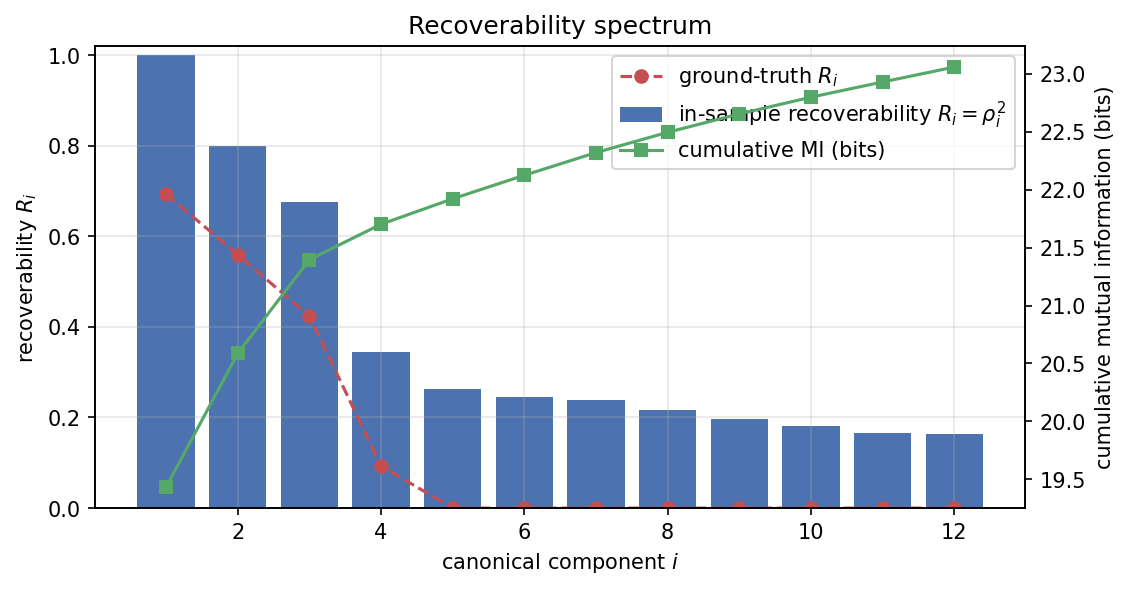

cv_recoverability


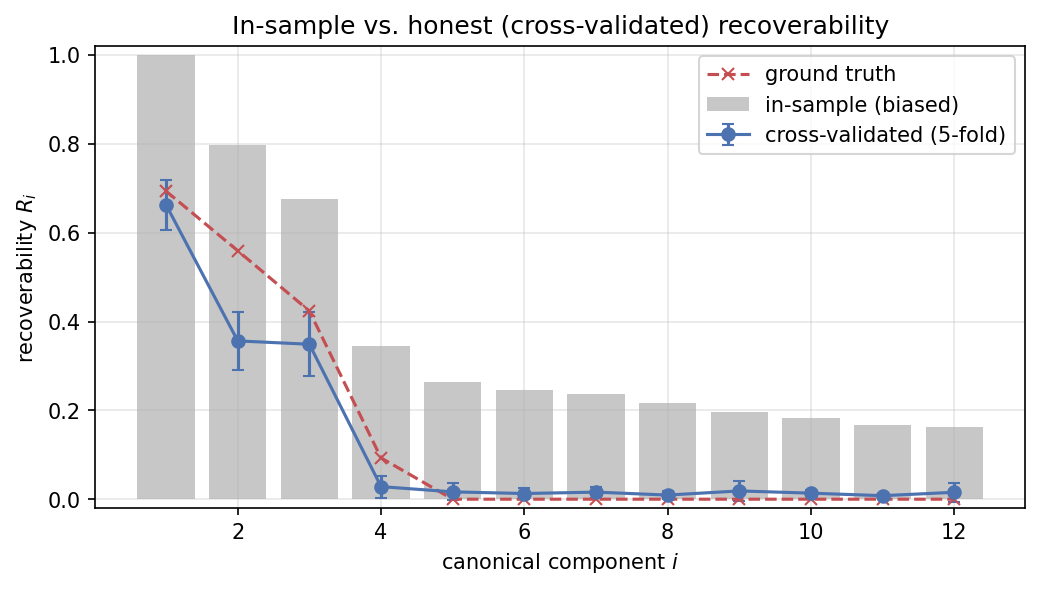

synthetic_truth_validation


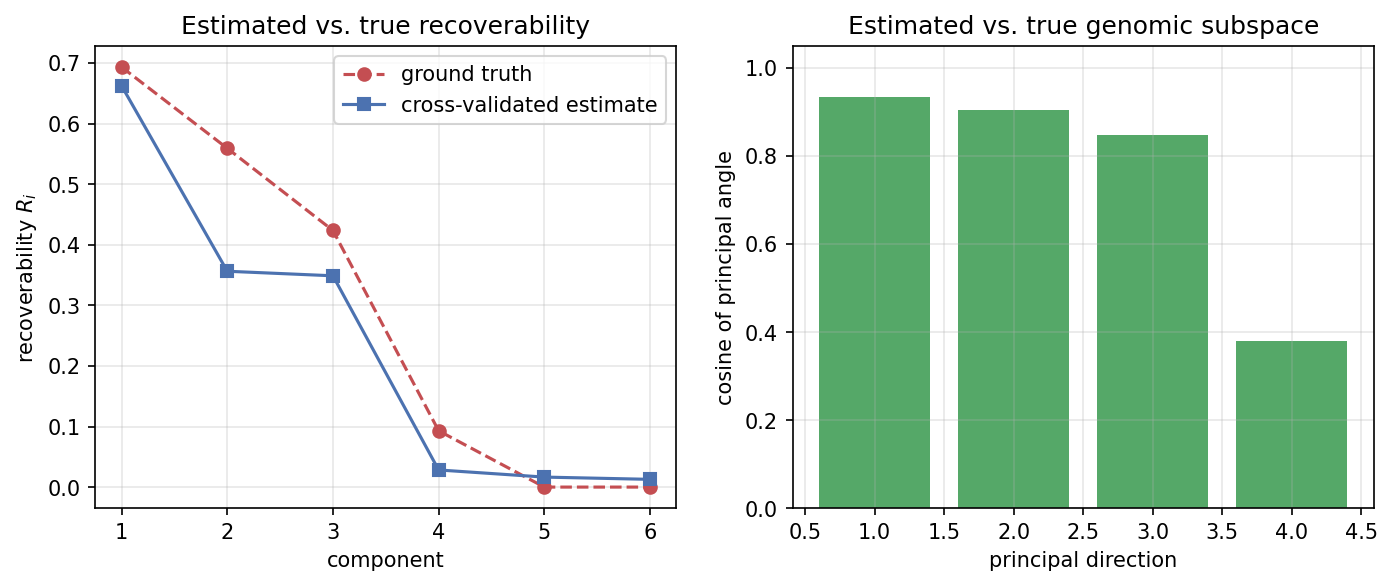

In [6]:
from IPython.display import Image, display

figdir = Path("intro_out") / "figures"
for name in ["recoverability_spectrum", "cv_recoverability", "synthetic_truth_validation"]:
    p = figdir / f"{name}.png"
    if p.exists():
        print(name)
        display(Image(filename=str(p)))

## 3 · Plug in **your own** two AnnData files

Point the three settings below at your data and run the cell. Reminders:

- `obs_names` must be patient IDs that overlap between the two files.
- For mutation data set `genomics_data_type="variant"` and make `.X` a `{0, 1}` matrix.
- Defaults assume **raw RNA-seq counts** (CPM + log1p + HVG selection are on). If
  your expression is already normalized (e.g. microarray / log-intensities), add
  `do_cpm_normalization=False, do_log1p=False` to the config below.
- Everything else has sensible defaults (see *Configuration* below to tweak).

The cell is guarded so this notebook still runs top-to-bottom on the synthetic
example when the paths don't exist yet.

In [7]:
# ============================================================================
#  PLUG AND PLAY — edit these three lines, then run the cell.
# ============================================================================
GENOMICS_H5AD      = "path/to/your/genomics.h5ad"   # patients × genes
IMAGING_H5AD       = "path/to/your/imaging.h5ad"    # patients × imaging features
GENOMICS_DATA_TYPE = "expression"                    # "expression" or "variant"
OUTPUT_DIR         = "my_analysis_out"
# ============================================================================

if Path(GENOMICS_H5AD).exists() and Path(IMAGING_H5AD).exists():
    my_report = rgit.run_recoverability_analysis(
        rgit.RecoverabilityConfig(
            genomics_h5ad=GENOMICS_H5AD,
            imaging_h5ad=IMAGING_H5AD,
            genomics_data_type=GENOMICS_DATA_TYPE,
            output_dir=OUTPUT_DIR,
        )
    )
    print("done ->", my_report.stats_path)
    er = my_report.stats["effective_identifiable_rank"]
    print(f"effective identifiable rank: {er['rank']} of {er['K_tested']} tested")
    print(f"95% upper bound on I(G;X)  : "
          f"{my_report.stats['mi_upper_bound']['ucl_95_bits']:.2f} bits")
else:
    print("Set GENOMICS_H5AD / IMAGING_H5AD to real files above, then re-run this cell.")
    print("(Skipping for now so the notebook runs end-to-end on the synthetic example.)")

Set GENOMICS_H5AD / IMAGING_H5AD to real files above, then re-run this cell.
(Skipping for now so the notebook runs end-to-end on the synthetic example.)


## What you get, and how to tweak it

Each run writes to `output_dir/`:

- **`stats.json`** — every quantity (spectra, MI bounds, permutation summaries, …)
- **`config.json`** — the exact settings used, for provenance
- **`figures/`** — PDF + PNG of every plot

All knobs live on `rgit.RecoverabilityConfig`. A few you may want:

```python
rgit.RecoverabilityConfig(
    genomics_h5ad=..., imaging_h5ad=..., genomics_data_type="expression",
    use_copula=True,            # Gaussian-copula marginal transform (recommended)
    samples_per_dim=5,          # n / working-dim target after PCA reduction
    n_perm=200, n_folds=5,      # permutation / cross-validation effort
    deconfound=True,            # regress confounders out of BOTH modalities ...
    demographics_csv="demographics.csv",   # ... using this table
    save_figures=True,
)
```

Prefer the command line? The same thing, no notebook:

```bash
rgit-recoverability --genomics your_genomics.h5ad \
                    --imaging  your_imaging.h5ad \
                    --genomics-data-type expression \
                    --output-dir my_analysis_out
```

For the fully annotated, figure-by-figure analysis, open
`radiogenomic_recoverability.ipynb`.